In [68]:
import pandas as pd
import numpy as np
import xarray as xr

import matplotlib.pyplot as plt
import os
from pathlib import Path
import seaborn as sns
from scipy.stats import wasserstein_distance
from matplotlib.pyplot import tight_layout

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.inspection import permutation_importance

label_dict  = {}
label_dict['huber_value'] = r"Huber $\mathcal{H}$"
label_dict['stem_hydraulic_capacitance'] = r"$\Gamma_\mathrm{Stem, max}$"
label_dict['stem_hydraulic_capacitance_res'] = r"$\Gamma_\mathrm{Stem_res}$"
label_dict['leaf_hydraulic_capacitance'] = r"$\Gamma_\mathrm{Leaf}$"
label_dict['g0'] = r"$g_0$"
label_dict['g1'] = r"$g_1$"
label_dict['k_xylem_sat'] = r"$K_\mathrm{xyl, max}$"
label_dict['psi50_xylem'] = r"$\psi_{50}$"
label_dict['psi88_xylem'] = r"$\psi_{88}$"
label_dict['wcont_sigma_deviation'] = r"$\sigma_\mathrm{wcont}$"
label_dict['pore_0'] = r"$\xi$"
label_dict['jackson_root_beta'] = r"$\mathrm{Root}_\beta$"
label_dict['psi_leaf_50_close'] = r"$\psi_{Leaf, close}$"
label_dict['d_50_close'] = r"$d_{Leaf, close}$"
label_dict['alpha'] = r"$\alpha$"
label_dict['gam_stem_x_H'] = r"$\Gamma_\mathrm{Stem} \cdot \mathcal{H}$"
label_dict['gam_stem_div_g0'] = r"$\frac{g_0}{\Gamma_\mathrm{Stem}}$"
label_dict['k_xyl_x_H'] = r"$K_\mathrm{xyl, max}\cdot \mathcal{H}$"
label_dict['g_min_loss'] = r"$g_0 + g_\mathrm{Bark}$"
label_dict['g_min_loss'] = r"$g_0 + g_\mathrm{Bark}$"
label_dict['wcont_sigma_deviation'] = r"$\sigma_\mathrm{wcont}$"
label_dict['p50-p88'] =  r"$\psi_{50} - \psi_{88} $"
label_dict['g0_div_gam_stem_x_H'] =  r"g0_div_gam_stem_x_H"
label_dict['g0_div_gam_stem_x_H'] =  r"g0_div_gam_stem_x_H"
label_dict['k_soil_sat0'] =  r"k_soil_sat"
label_dict['root_area_index'] =  r"RAI"
label_dict['psi_tlp'] = r'$\psi_\mathrm{tlp}$'



unit_dict= {}
unit_dict['stem_hydraulic_capacitance'] = "kg m-3 MPa-1"
unit_dict['stem_hydraulic_capacitance_res'] = "kg m-3 MPa-1"
unit_dict['leaf_hydraulic_capacitance'] = "kg m-2 MPa-1"
unit_dict['k_xylem_sat'] = "kg m-1 s-1 MPa-1"
unit_dict['huber_value'] = "cm2 m-2"
unit_dict['psi50_xylem'] = "MPa"
unit_dict['psi88_xylem'] = "MPa"
unit_dict['g0'] = "mol m-1 s-1"
unit_dict['g1'] = "-"
unit_dict['g_stem_res'] = "mol m-1 s-1"
unit_dict['psi_leaf_50_close'] = r"MPa"
unit_dict['d_50_close'] = "-"
unit_dict['alpha'] = r"-"
unit_dict['gam_stem_x_H'] = r"-"
unit_dict['gam_stem_div_g0'] = r"-"
unit_dict['k_xyl_x_H'] =r"-"
unit_dict['g_min_loss'] = r"-"
unit_dict['wcont_sigma_deviation'] = r"-"
unit_dict['p50-p88'] =  "MPa"
unit_dict['psi_tlp'] =  "MPa"
unit_dict['g0_div_gam_stem_x_H'] =  "-"
unit_dict['pore_0'] =  "-"
unit_dict['k_soil_sat0'] =  "m s-1"
unit_dict['root_area_index'] =  "m2 m-2"


root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_other_soil_other_cstem"
scenario_name = "big_overview_20_10000p"

root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_2024_final"
scenario_name = "big_overview_20_10000p_fine_g1fix_relay"

root_output_directory = "/Net/Groups/BSI/scratch/ppapastefanou/simulations/SimPHony/swiss_cc/"
scenario_name = "45_LHS_TLP"
nmax = 1000
#scenario_name = "23_ex_con_2025_full_logit_mean_one_wcont"

input_path = os.path.join(root_output_directory, scenario_name, 'input')
output_path = os.path.join(root_output_directory, scenario_name, 'output')
post_path = os.path.join(root_output_directory, scenario_name, 'post')
vars_all = ['psi_leaf_50_close', 'd_50_close', 'stem_hydraulic_capacitance', 'k_xylem_sat', 'huber_value',
        'leaf_hydraulic_capacitance', 'psi50_xylem', 'psi88_xylem', 'g0', 'k_soil_sat0', 'psi_soil_sat0', 'jackson_root_beta',
        'pore_0', 'root_area_index', 'wcont_sigma_deviation', 'alpha', 'g_stem_res','gam_stem_x_H','k_xyl_x_H', 
        'g0_div_gam_stem_x_H', 'g_min_loss', 'p50-p88', 'g1', 'psi_tlp']

vars_all.append('stem_hydraulic_capacitance_res')

vars_plant = ['stem_hydraulic_capacitance', 'k_xylem_sat', 'huber_value', 'leaf_hydraulic_capacitance', 'psi50_xylem',
              'g0','psi_leaf_50_close', 'd_50_close', 'alpha','psi88_xylem']

vars_plant_ex = ['stem_hydraulic_capacitance', 'k_xylem_sat', 'huber_value', 'leaf_hydraulic_capacitance', 'psi50_xylem',
              'g0','psi_leaf_50_close', 'd_50_close', 'alpha','psi88_xylem', 'gam_stem_x_H','k_xyl_x_H', 'g0_div_gam_stem_x_H', 'g_min_loss']
vars_all_ex = vars_all.copy()
vars_all_ex.append("RMSE_MAX")

df = pd.read_csv(os.path.join(post_path, f"All_RMSE_{nmax}.csv"))
df['stem_hydraulic_capacitance'] *= 18.0/1000.0
df['stem_hydraulic_capacitance_res'] *= 18.0/1000.0
df['huber_value'] *= 10000.0
df['k_xylem_sat'] *= 18.0/1000.0
df['alpha'] = df['g_stem_res']/ df['g0']
df['gam_stem_x_H'] = df['stem_hydraulic_capacitance'] * df['huber_value']
df['k_xyl_x_H'] = df['k_xylem_sat'] * df['huber_value']
df['g0_div_gam_stem_x_H'] =  df['g0']/df['stem_hydraulic_capacitance']* df['huber_value']
df['g_min_loss'] = df['g0'] + df['g_stem_res']
df['p50-p88'] = df['psi50_xylem'] - df['psi88_xylem']


df.loc[df['sid'] ==0, 'sid'] =1 
df.loc[df['sid'] ==-1, 'sid'] =0 
df.loc[df['sid'] ==3, 'sid'] =2
df.loc[df['sid'] ==6, 'sid'] =3 
df.loc[df['sid'] ==7, 'sid'] =4 

index_to_drop = df[(df['sid']==2)|(df['sid']==2)|(df['sid']==2)].index
df.drop(index_to_drop, inplace=True)

dv = df[vars_all]
dv['leaf_hydraulic_capacitance'] = np.log10(dv['leaf_hydraulic_capacitance'])
df_mean = dv


df_norm = (df_mean - df_mean.mean()) / df_mean.std()


df_norm['sid'] = df['sid']
df_norm['alive'] = 1
df_norm.loc[df_norm['sid'] > 0, 'alive'] = 0

df_norm["sid_group"] = df_norm["sid"].apply(lambda s: "sid 0" if s == 0 else "other")
palette = {"sid 0": "tab:blue", "other": "tab:red"}

/tmp/ipykernel_4041982/3968715271.py:126: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dv['leaf_hydraulic_capacitance'] = np.log10(dv['leaf_hydraulic_capacitance'])


In [69]:
# Multiple variables
vars_to_compare = [
    "stem_hydraulic_capacitance", "g0"
    # add more variables here, e.g. "xylem_conductivity", "leaf_area_index"
]
vars_to_compare = [
    'psi_leaf_50_close',
 #'d_50_close',
 'stem_hydraulic_capacitance',
 'stem_hydraulic_capacitance_res',
 'k_xylem_sat',
 'huber_value',
 #'leaf_hydraulic_capacitance',
 #'psi50_xylem',
 'psi88_xylem',
 'p50-p88',
 #'g0',
 #'jackson_root_beta',

 #'root_area_index',
 'wcont_sigma_deviation',
 #'alpha',
 #'g_stem_res',
 #'#gam_stem_x_H',
 #'k_xyl_x_H',
 #'g0_div_gam_stem_x_H',
 #'g_min_loss', 'g1',
  'psi_tlp' ]

['k_soil_sat0',
 'psi_soil_sat0', 'pore_0',]


['k_soil_sat0', 'psi_soil_sat0', 'pore_0']

In [70]:
from sklearn.cluster import KMeans
import seaborn as sns
from sklearn.metrics import silhouette_score

In [71]:
from sklearn.decomposition import PCA

In [72]:
pca = PCA(n_components=4)  # reduce to 2 components for visualization
principal_components = pca.fit_transform(df_norm[vars_to_compare])

In [73]:
print("Explained variance ratio:", pca.explained_variance_ratio_)

Explained variance ratio: [0.32014308 0.18576115 0.13641801 0.11410369]


In [74]:
df_norm

,psi_leaf_50_close,d_50_close,stem_hydraulic_capacitance,k_xylem_sat,huber_value,leaf_hydraulic_capacitance,psi50_xylem,psi88_xylem,g0,k_soil_sat0,...,k_xyl_x_H,g0_div_gam_stem_x_H,g_min_loss,p50-p88,g1,psi_tlp,stem_hydraulic_capacitance_res,sid,alive,sid_group
0,-1.039056,0.388394,-1.044841,0.106214,0.397511,1.297176,-1.909920,-1.931430,-0.237847,0.999875,...,0.284853,1.008051,-1.099463,1.519329,1.283315,-0.035511,1.251762,1,0,other
1,-0.232937,0.530577,0.227260,1.421064,-0.935096,1.498290,-0.652772,-1.269369,0.126801,0.999875,...,0.967782,-0.844717,0.588075,1.422479,0.668120,-0.339218,1.046292,1,0,other
2,-0.548241,1.847993,-1.672960,0.660675,0.560019,1.524289,-1.862847,-1.310689,-0.536296,0.999875,...,0.933481,1.668949,0.776602,0.632208,0.246273,-1.173592,0.892840,1,0,other
3,-0.687848,0.624429,0.307947,1.316217,0.658561,1.112033,-1.084897,-1.371165,0.316367,0.999875,...,1.677559,0.265135,-0.547037,1.269306,-0.575928,1.342461,1.215987,1,0,other
4,-0.969213,0.440641,-0.877437,1.565677,0.697716,1.502476,-1.675368,-0.663882,1.495553,0.999875,...,1.965158,1.630159,0.029587,-0.194752,0.372322,-0.595314,1.246003,1,0,other
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,-1.066947,-0.764866,-0.352558,-1.366520,-0.043230,-1.107167,-0.998928,-0.822138,1.964889,0.999875,...,-1.348036,0.696018,0.746800,0.515872,-1.705791,0.175853,-0.895283,0,1,sid 0
4996,-1.167310,-0.999864,0.552159,-0.551582,0.204227,0.190106,-1.108840,-0.681209,0.563394,0.999875,...,-0.460240,-0.153450,1.823585,0.229600,0.064116,0.251277,0.677592,0,1,sid 0
4997,-0.913507,0.308121,-1.344392,-1.384961,1.164155,-0.744462,1.300839,0.282255,1.468668,0.999875,...,-1.099868,2.509913,0.547828,0.496957,-0.796144,1.032477,-0.981154,0,1,sid 0
4998,-1.202194,-0.769974,1.414139,0.119235,-0.265128,-0.217079,-0.715815,-1.253039,1.103662,0.999875,...,0.047359,-0.855271,0.047124,1.353906,1.397096,-0.634329,0.296233,0,1,sid 0


In [81]:
dd = df_norm[df_norm['alive']==0]
dd = df_norm

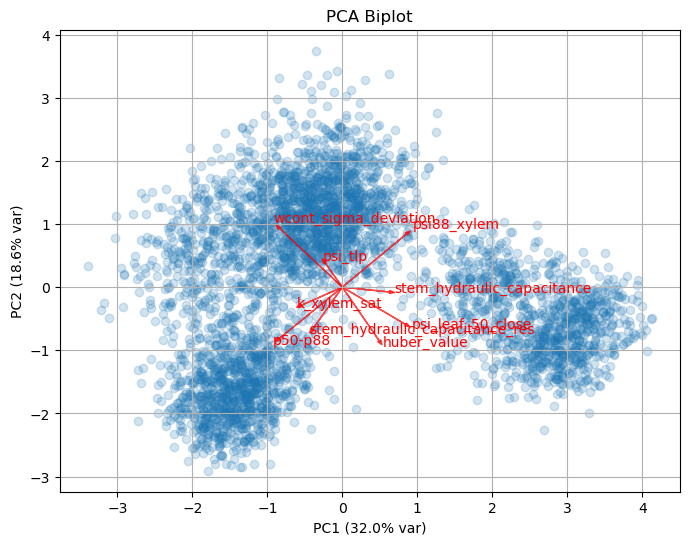

In [82]:
X_pca = pca.fit_transform(dd[vars_to_compare])

# --- 3. Create biplot ---
plt.figure(figsize=(8, 6))

# Plot samples
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.2)

# Plot arrows for loadings
loadings = pca.components_.T  # each column is a principal component
for i, feature in enumerate(dd[vars_to_compare].columns):
    plt.arrow(0, 0,
              loadings[i, 0] * 2,  # scale up for visibility
              loadings[i, 1] * 2,
              color='r', alpha=0.7, head_width=0.05)
    plt.text(loadings[i, 0] * 2.2, loadings[i, 1] * 2.2, feature, color='r')

# Axes labels
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
plt.title("PCA Biplot")
plt.grid()
plt.show()

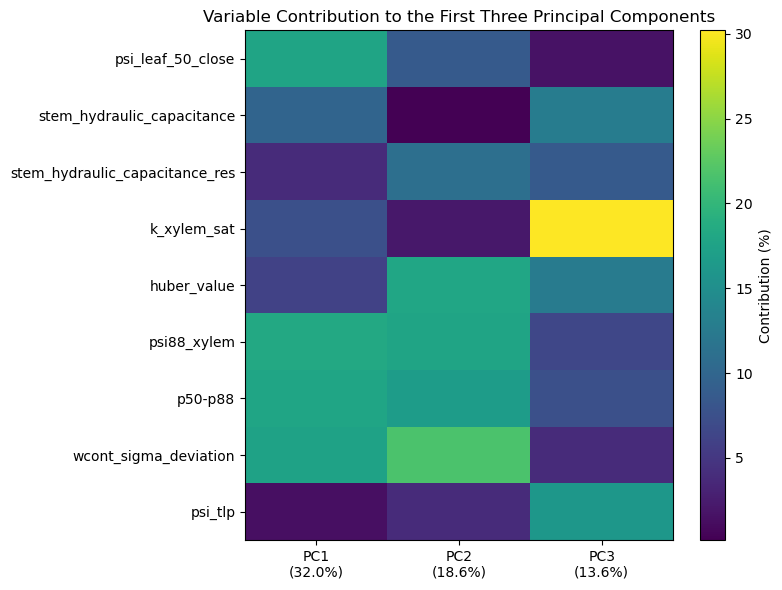

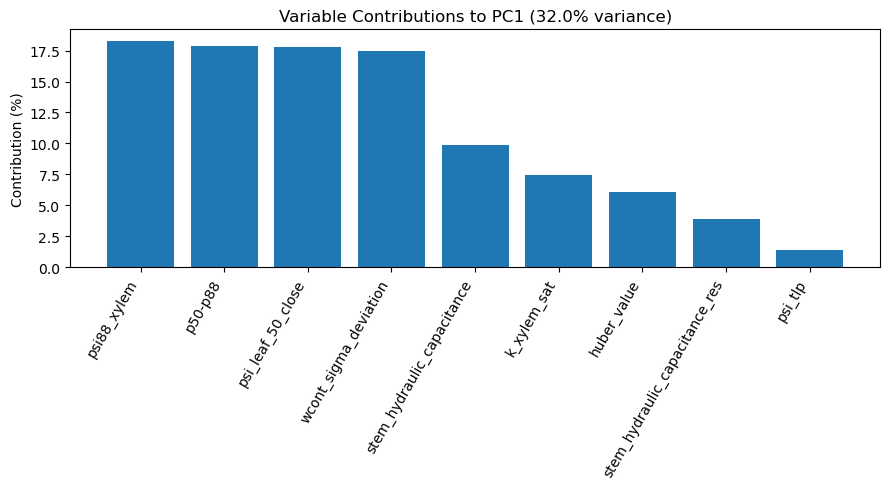

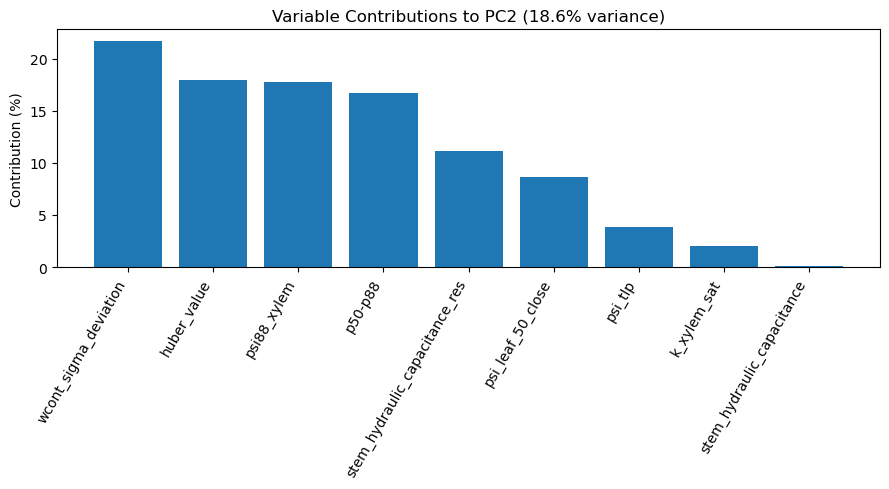

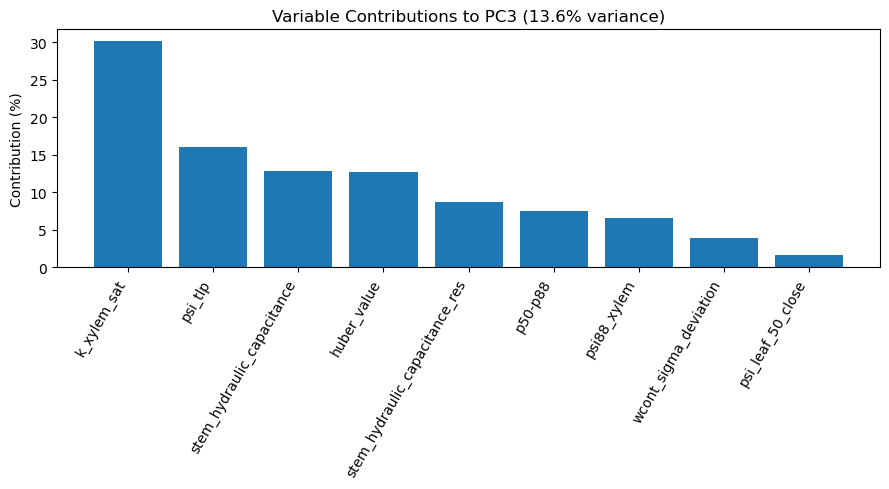

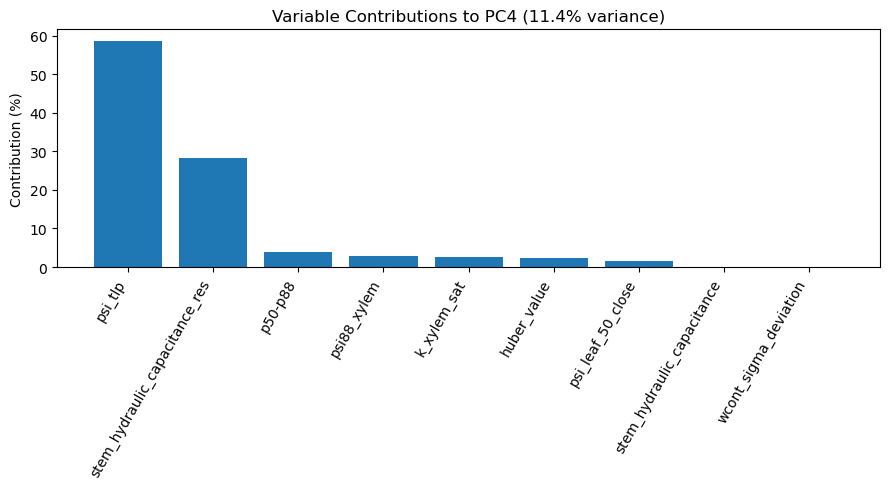

In [83]:
# --- 3. Compute loadings and contributions ---
eigenvalues = pca.explained_variance_
loadings = pca.components_.T * np.sqrt(eigenvalues)
contrib = (loadings**2 / eigenvalues) * 100  # variable contributions (%)

# --- 4A. Heatmap of contributions (PC1–PC3) ---
plt.figure(figsize=(8, 6))
plt.imshow(contrib[:, :3], aspect='auto', interpolation='nearest', cmap='viridis')
plt.colorbar(label='Contribution (%)')
plt.yticks(np.arange(len(vars_to_compare)), vars_to_compare)
plt.xticks(np.arange(3),
           [f"PC{i+1}\n({pca.explained_variance_ratio_[i]*100:.1f}%)"
            for i in range(3)])
plt.title("Variable Contribution to the First Three Principal Components")
plt.tight_layout()
plt.show()

# --- 4B. Bar plots for PC1–PC3 ---
for k in range(4):
    order = np.argsort(contrib[:, k])[::-1]
    plt.figure(figsize=(9, 5))
    plt.bar(np.array(vars_to_compare)[order], contrib[order, k])
    plt.ylabel("Contribution (%)")
    plt.title(f"Variable Contributions to PC{k+1} "
              f"({pca.explained_variance_ratio_[k]*100:.1f}% variance)")
    plt.xticks(rotation=60, ha='right')
    plt.tight_layout()
    plt.show()

In [2]:
from sklearn.decomposition import KernelPCA

In [11]:
kpca = KernelPCA(n_components=3)  # reduce to 2 components for visualization
principal_components = pca.fit_transform(df_norm[vars_to_compare])

lambdas = kpca.lambdas_
explained_var_ratio = lambdas/np.sum(lambdas)
print("Explained variance ratio (PC1..PC3):", explained_var_ratio[:3])

AttributeError: 'KernelPCA' object has no attribute 'lambdas_'

In [ ]:
kmeans = KMeans(n_clusters = 3, random_state = 0, n_init='auto')
kmeans.fit(df_norm[vars_to_compare])



NameError: name 'KMeans' is not defined

In [103]:
K = range(2, 12)
fits = []

scorss = []
for s in range(10):
    score = []
    for k in K:
        # train the model for current value of k on training data
        model = KMeans(n_clusters = k, random_state = s, n_init='auto').fit(df_norm[vars_to_compare])

        # append the model to fits
        fits.append(model)

        # Append the silhouette score to scores
        score.append(silhouette_score(df_norm[vars_to_compare], model.labels_, metric='euclidean'))
    scorss.append(score)
    print(s)


0
1
2
3
4
5
6
7
8
9


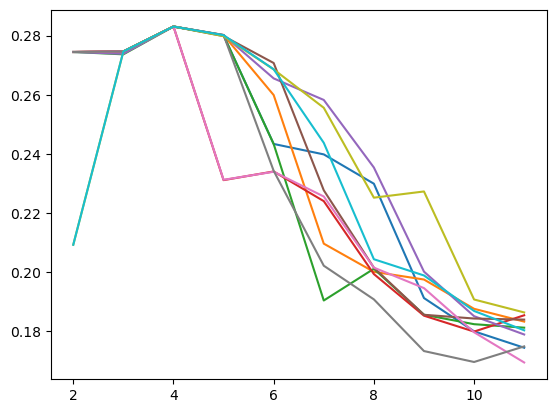

In [104]:
plt.plot(K, np.array(scorss).T);

In [105]:
kmeans = KMeans(n_clusters = 4, random_state = 9
                , n_init='auto')
kmeans.fit(df_norm[vars_to_compare])
np.round(silhouette_score(df_norm[vars_to_compare], kmeans.labels_, metric='euclidean'),3)


np.float64(0.283)

In [106]:
unique, counts = np.unique(kmeans.labels_, return_counts=True)
counts
countslabs = [f'G{i+1} ({counts[i]})'for i in range(4)]


In [20]:
vars_sel = vars_plant_ex

/tmp/ipykernel_3821741/4076545182.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(countslabs)
/tmp/ipykernel_3821741/4076545182.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(countslabs)
/tmp/ipykernel_3821741/4076545182.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(countslabs)
/tmp/ipykernel_3821741/4076545182.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(countslabs)
/tmp/ipykernel_3821741/4076545182.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(countsl

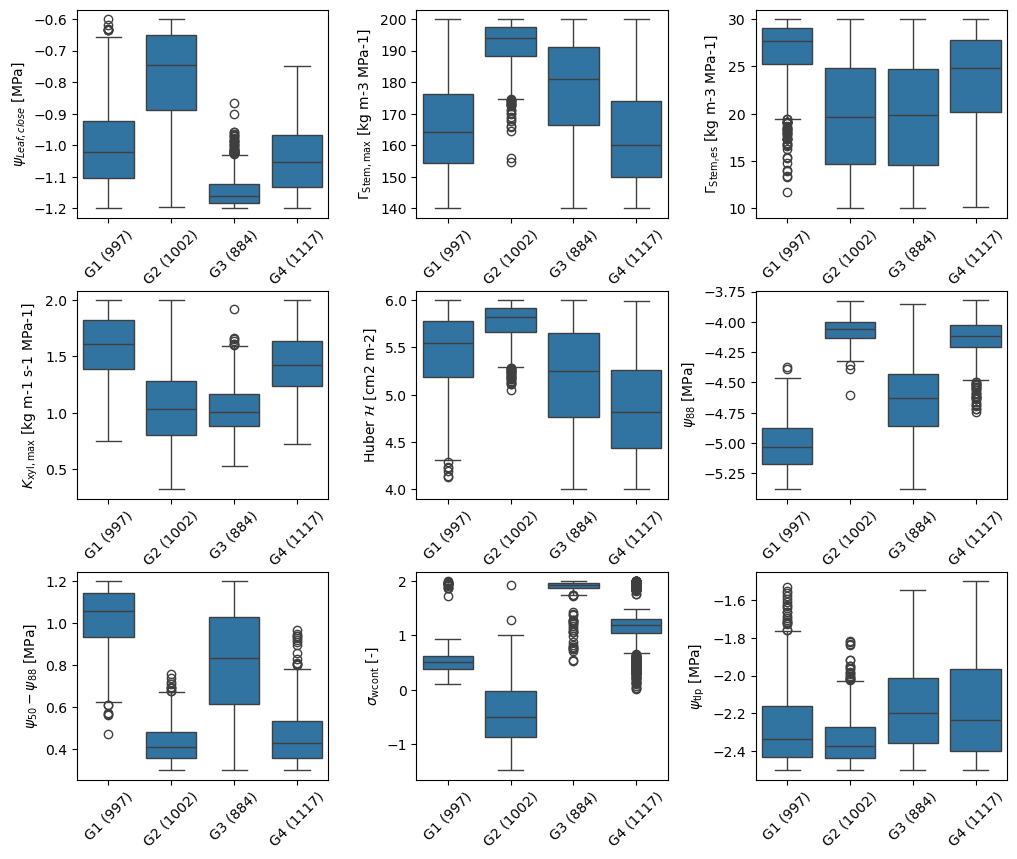

In [107]:
MOL_TO_KG = 18.0/1000.0 
plt.rcParams["font.family"] = "Avenir"
fig = plt.figure(figsize = (12,10))
for index,  var in zip(np.arange(1, 12+1), vars_to_compare):
    ax = fig.add_subplot(3,3, index)
    ax.set_xticklabels(countslabs)
    ax.set_ylabel(f"{label_dict[vars_to_compare[index-1]]} [{unit_dict[vars_to_compare[index-1]]}]")
    

    sns.boxplot(x = kmeans.labels_, y = df_mean[var], ax=ax)
    ax.tick_params(axis='x', labelrotation=45)

plt.subplots_adjust(wspace=0.35, hspace=0.35)
plt.savefig(f"{post_path}/figure4_kmeans_cluster.png", bbox_inches='tight', dpi = 300)

In [28]:
from sklearn.cluster import MeanShift
from sklearn import metrics

db = MeanShift(bandwidth=2).fit(df_norm[vars_plant])

labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)
print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)
print(f"Silhouette Coefficient: {metrics.silhouette_score(df_norm[vars_plant], db.labels_,metric='euclidean'):.3f}")

KeyboardInterrupt: 

In [16]:
df_norm[vars_plant]

,stem_hydraulic_capacitance,k_xylem_sat,huber_value,leaf_hydraulic_capacitance,psi50_xylem,psi88_xylem,g0,jackson_root_beta
id,,,,,,,,
0,-0.601464,1.145214,0.593686,1.227873,-2.142011,-2.047083,-0.991387,-0.736660
1,-0.505121,-0.872027,-0.098686,-0.794584,1.755737,1.980279,-1.392011,0.734571
2,1.412511,0.534290,0.514407,-0.280269,1.284822,1.306727,1.622993,2.429507
3,0.598750,-0.964184,0.907454,-0.669782,0.260972,1.040270,0.425506,0.440895
4,-0.263877,0.727996,0.548335,1.939314,0.978791,0.045805,0.180179,-0.495927
...,...,...,...,...,...,...,...,...
23694,-0.113747,0.276975,1.328484,1.707235,-0.075766,0.262491,2.640747,-1.652910
23695,-0.601057,-0.126646,-0.997181,-0.805152,1.175334,0.476110,-0.954902,0.152204
23696,0.553392,0.628877,0.964663,0.057998,0.602677,1.493658,0.034281,0.840595


In [ ]:
unique, counts = numpy.unique(a, return_counts=True)

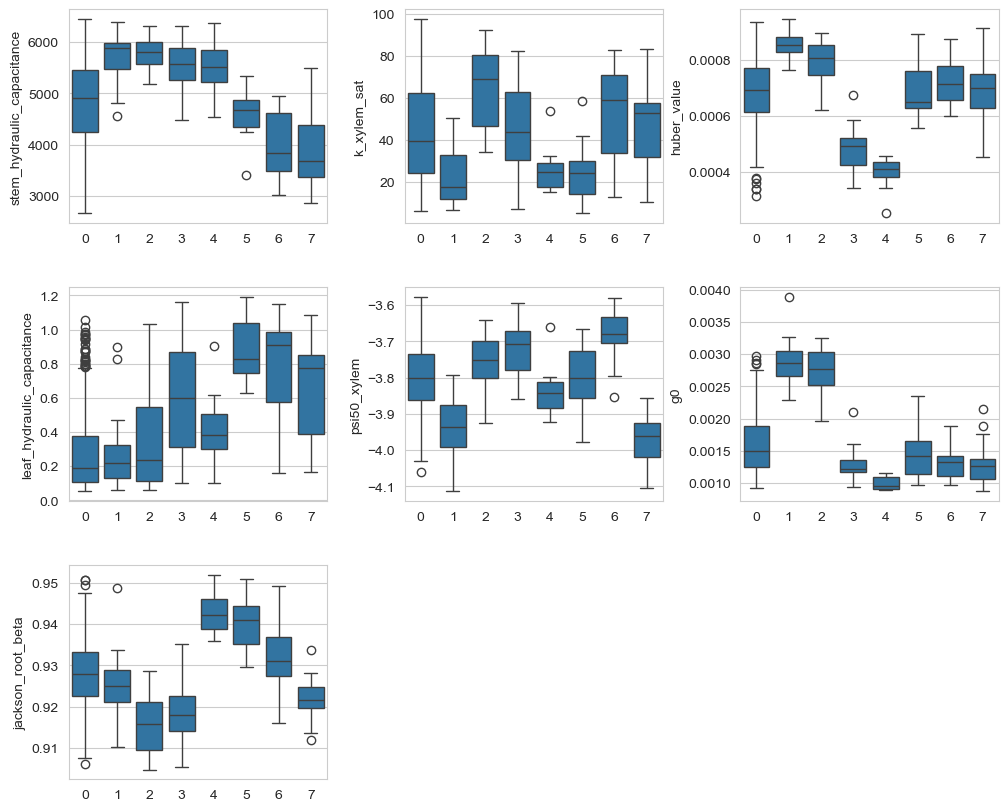

In [40]:
fig = plt.figure(figsize = (12,10))
for index,  var in zip(np.arange(1, len(vars_plant)+1), vars_plant):
    ax = fig.add_subplot(3,3, index)
    sns.boxplot(x = labels, y = df_mean[var], ax=ax)
fig.subplots_adjust(wspace=0.3, hspace=0.3)

findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not

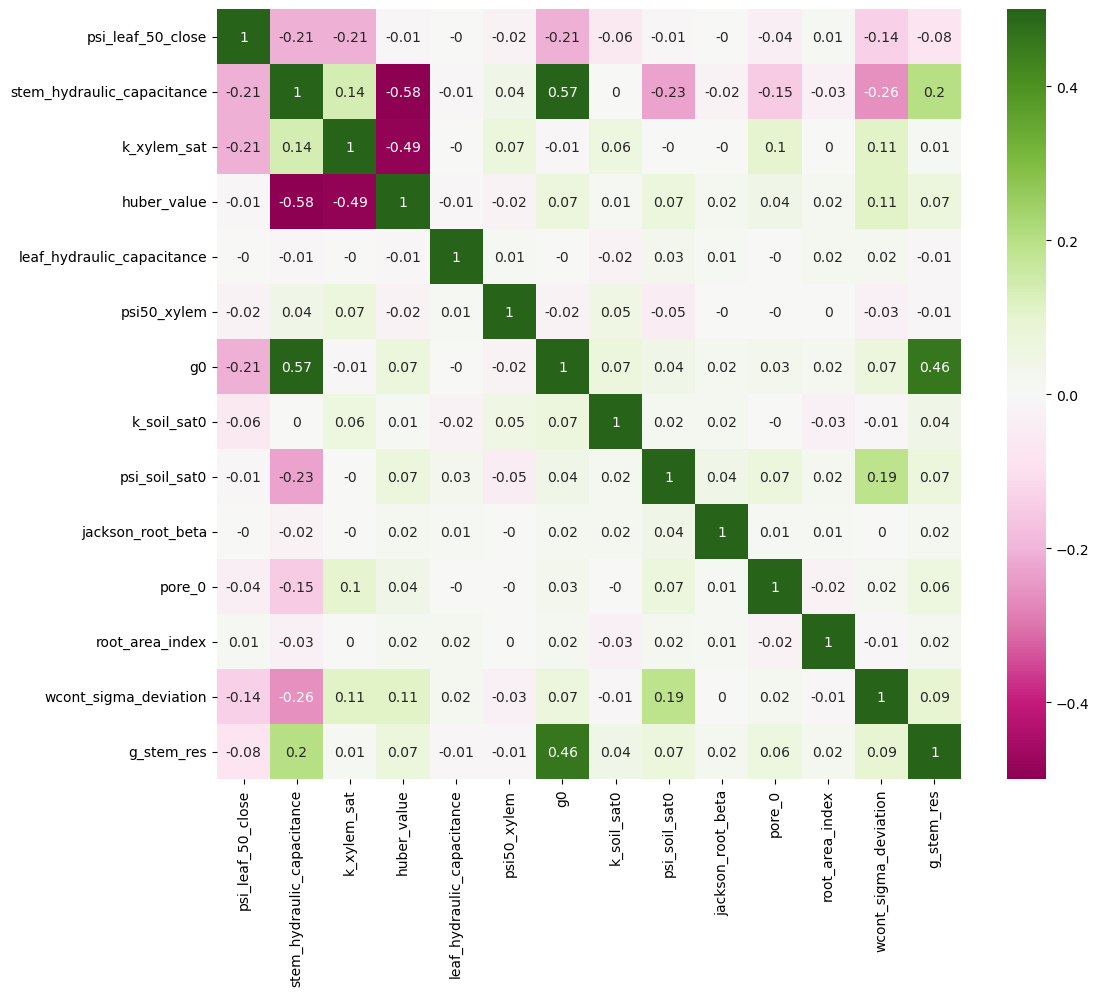

In [29]:
corr_matrix = df_mean.corr(method='spearman').round(2)
#corr_matrix.style.background_gradient(cmap='Greens')
plt.figure(figsize = (12,10))
sns.heatmap(corr_matrix, annot=True, vmin=-0.5, vmax=0.5, cmap="PiYG")
plt.savefig(f"{post_path}/figure_corelation4.png", bbox_inches='tight', dpi = 300)